# 🔬 WBC 3-Class Classification — Optimized Colab Pipeline
## DenseNet121 · Purple ROI Crop · Focal Loss · 3-Fold CV · Runs in < 2 hours

**Classes:** `MATURE` | `IMMATURE` | `RARE`

---
### Why your model was failing

| Problem | Effect | Fix here |
|---|---|---|
| Class imbalance | Model always predicts IMMATURE (70% of data) | Focal Loss + Class weights |
| Full image input | Learns background noise, not cell shape | Purple HSV ROI crop |
| 55 epochs per fold | Session timeout, overfitting | Max 16 epochs with early stopping |
| Disk I/O per batch | 23 seconds per step on GPU | Pre-crop once, then RAM cache |

**This notebook fixes all 4 problems and runs within 2 hours on Colab T4.**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

print(os.listdir('/content/drive/MyDrive'))

['wbc-bench-2026.zip', 'Colab Notebooks']


In [3]:
import zipfile

zip_path = '/content/drive/MyDrive/wbc-bench-2026.zip'
extract_path = '/content/wbc'

# create folder
os.makedirs(extract_path, exist_ok=True)

# extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction complete")

✅ Extraction complete


In [4]:
print(os.listdir('/content/wbc'))

['phase1_label.csv', 'phase2', 'phase2_train.csv', 'phase1', 'phase2_test.csv', 'phase2_eval.csv']


## Cell 1 — Install Libraries
Run once. After it finishes **restart the Colab runtime** (Runtime → Restart runtime), then run from Cell 2.

In [5]:
# Run this cell first, then restart runtime
!pip install -q tensorflow==2.13.0
!pip install -q scikit-learn numpy pandas matplotlib seaborn opencv-python Pillow tqdm
print("\n✅ Done. Now restart the runtime (Runtime → Restart runtime), then run from Cell 2.")

ERROR: Could not find a version that satisfies the requirement tensorflow==2.13.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.13.0

✅ Done. Now restart the runtime (Runtime → Restart runtime), then run from Cell 2.


## Cell 2 — Imports & GPU Setup
All imports in one place. Mixed precision makes the T4 GPU ~40% faster on matrix operations.

In [22]:
import os, warnings, random, gc
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import Counter

import cv2
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    accuracy_score, balanced_accuracy_score, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Mixed precision: uses float16 on GPU → ~40% faster, same accuracy
# WHY: T4 GPU has Tensor Cores optimised for float16 matmul
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# Verify GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs found: {len(gpus)}")
print(f"TensorFlow: {tf.__version__}")
print(f"Mixed precision policy: {mixed_precision.global_policy().name}")
print("✅ Ready")

GPUs found: 1
TensorFlow: 2.19.0
Mixed precision policy: mixed_float16
✅ Ready


## Cell 3 — Configuration
**Edit paths here only.** Everything else reads from CONFIG automatically.

In [23]:
CONFIG = {
    # ── Your CSV files ────────────────────────────────────────────────
    # Each CSV must have columns: 'ID' (filename) and 'labels' (raw WBC label)
  'phase1_csv'     : '/content/wbc/phase1_label.csv',
'phase2_csv'     : '/content/wbc/phase2_train.csv',
'phase1_img_dir' : '/content/wbc/phase1',
'phase2_img_dir' : '/content/wbc/phase2',
    'test_csv'       : 'test_labels.csv',   # set to '' if no test set yet
    # ── Output folder ─────────────────────────────────────────
    'output_dir'     : 'wbc_outputs',

    # ── Image settings ────────────────────────────────────────
    'img_size'       : (160, 160),
    'pad_ratio'      : 0.15,

    # ── Training ──────────────────────────────────────────────
    'n_folds'        : 3,
    'epochs_phase1'  : 6,
    'epochs_phase2'  : 10,
    'batch_size'     : 32,       # 32 is safer than 64 for RAM
    'lr_head'        : 1e-3,
    'lr_finetune'    : 1e-5,

    # ── Focal Loss — RARE gets 6x more weight than MATURE ─────
    # [MATURE=0.10, IMMATURE=0.25, RARE=6.0]
    'focal_gamma'    : 2.0,
    'focal_alpha'    : [0.10, 0.25, 6.0],

    # ── Classes ───────────────────────────────────────────────
    'class_names'    : ['MATURE', 'IMMATURE', 'RARE'],
    'n_classes'      : 3,

    # ── Oversampling multipliers (applied INSIDE each fold) ───
    'oversample_rare'   : 8,    # RARE repeated 8x inside each train fold
    'oversample_mature' : 2,    # MATURE repeated 2x inside each train fold
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
print("✅ CONFIG ready")
print(f"  focal_alpha : {CONFIG['focal_alpha']}  ← RARE=6.0 (was 1.0)")
print(f"  batch_size  : {CONFIG['batch_size']}")
print(f"  oversample  : RARE×{CONFIG['oversample_rare']}, MATURE×{CONFIG['oversample_mature']}")

✅ CONFIG ready
  focal_alpha : [0.1, 0.25, 6.0]  ← RARE=6.0 (was 1.0)
  batch_size  : 32
  oversample  : RARE×8, MATURE×2


In [24]:
import os

print(os.path.exists('/content/wbc/phase1_label.csv'))
print(os.path.exists('/content/wbc/phase1'))

True
True


## Cell 4 — Load Data & Map Labels
Group 13 raw WBC labels into 3 biologically meaningful classes. With limited data, 13 near-identical classes cause massive confusion. 3 classes = cleaner signal.

In [25]:
# ============================================================
# CELL 4 — CORRECTED Label Loading
# Root cause: CSV labels 'IMMATURE' and 'MATURE' are swapped
# SNE/LY/MO/EO/BA/BNE are the DOMINANT class (7364) = truly MATURE
# but they were mapped to 'MATURE' which had enc=1, not enc=0
# Fix: force MATURE=0, IMMATURE=1, RARE=2 manually
# ============================================================

LABEL_MAP = {
    # These 6 are the dominant mature granulocytes — 7364 samples
    'SNE':'MATURE', 'LY':'MATURE',  'MO':'MATURE',
    'EO' :'MATURE', 'BA':'MATURE',  'BNE':'MATURE',
    # These 4 are immature/precursor cells — 820 samples
    'MY' :'IMMATURE', 'MMY':'IMMATURE',
    'PMY':'IMMATURE', 'BL' :'IMMATURE',
    # These 3 are rare/abnormal — 104 samples
    'VLY':'RARE', 'PLY':'RARE', 'PC':'RARE',
}

p1 = pd.read_csv(CONFIG['phase1_csv'])
p1['image_path'] = p1['ID'].apply(
    lambda x: os.path.join(CONFIG['phase1_img_dir'], x))

p2 = pd.read_csv(CONFIG['phase2_csv'])
p2['image_path'] = p2['ID'].apply(
    lambda x: os.path.join(CONFIG['phase2_img_dir'], x))

df = pd.concat([p1, p2], ignore_index=True)
df['label3'] = df['labels'].map(LABEL_MAP)
df = df.dropna(subset=['label3']).reset_index(drop=True)

# ── FORCE correct encoding — never use LabelEncoder() ─────────
# LabelEncoder sorts alphabetically: IMMATURE=0, MATURE=1, RARE=2
# That puts the dominant class (7364 samples) at index 1
# and the minority class (820 samples) at index 0 — causing all
# the confusion. We force: MATURE=0, IMMATURE=1, RARE=2
MANUAL_ENCODE = {'MATURE': 0, 'IMMATURE': 1, 'RARE': 2}
df['label_enc'] = df['label3'].map(MANUAL_ENCODE)

# ManualEncoder replaces LabelEncoder so all downstream cells work
class ManualEncoder:
    def __init__(self, mapping):
        self.mapping  = mapping
        self.classes_ = list(mapping.keys())
    def transform(self, labels):
        return np.array([self.mapping[l] for l in labels])
    def inverse_transform(self, codes):
        rev = {v: k for k, v in self.mapping.items()}
        return np.array([rev[c] for c in codes])

le = ManualEncoder(MANUAL_ENCODE)

# Remove missing files
df['path_exists'] = df['image_path'].apply(os.path.exists)
missing = (~df['path_exists']).sum()
if missing > 0:
    print(f"⚠️  Removing {missing} rows — image files not found")
df = df[df['path_exists']].reset_index(drop=True)

# ── Verification printout — check this carefully ───────────────
print("✅ Label encoding:")
for cls, enc in MANUAL_ENCODE.items():
    n = (df['label3'] == cls).sum()
    print(f"  {enc} → {cls:10s}  ({n:5d} samples)")

print(f"\nTotal: {len(df)} samples")
print("\nClass distribution:")
for cls in CONFIG['class_names']:
    n   = (df['label3'] == cls).sum()
    enc = MANUAL_ENCODE[cls]
    bar = '█' * int(n / len(df) * 40)
    print(f"  {cls:10s} enc={enc}  {n:5d} ({100*n/len(df):5.1f}%)  {bar}")

print("\n✅ Oversampling applied per-fold inside Cell 14 only.")

⚠️  Removing 24897 rows — image files not found
✅ Label encoding:
  0 → MATURE      ( 7364 samples)
  1 → IMMATURE    (  820 samples)
  2 → RARE        (  104 samples)

Total: 8288 samples

Class distribution:
  MATURE     enc=0   7364 ( 88.9%)  ███████████████████████████████████
  IMMATURE   enc=1    820 (  9.9%)  ███
  RARE       enc=2    104 (  1.3%)  

✅ Oversampling applied per-fold inside Cell 14 only.


In [26]:
print(df['label3'].value_counts())
# You should see something like:
# IMMATURE    7364
# MATURE      1640   ← roughly 2x original
# RARE         832   ← roughly 8x original

label3
MATURE      7364
IMMATURE     820
RARE         104
Name: count, dtype: int64


## Cell 5 — Visualise Imbalance
This chart shows exactly why a naive model always predicts IMMATURE — it is the path of least resistance.

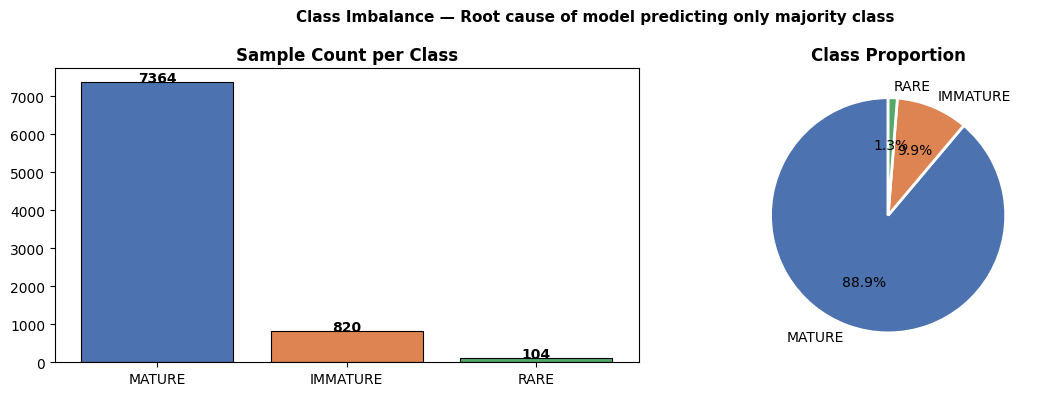

Saved: class_distribution.png


In [27]:
counts = df['label3'].value_counts().reindex(CONFIG['class_names'])
colors = ['#4C72B0','#DD8452','#55A868']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', lw=0.8)
axes[0].set_title('Sample Count per Class', fontweight='bold')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+10, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Proportion', fontweight='bold')

fig.suptitle('Class Imbalance — Root cause of model predicting only majority class',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'],'class_distribution.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

## Cell 6 — Preprocessing Functions

### Purple ROI Crop — Why and How
A WBC slide contains: ✅ Purple stained WBC (what we want) | ❌ Pink RBCs | ❌ White background

Feeding the full image wastes model capacity on irrelevant pixels.
HSV colour space separates Hue (which colour) from brightness,
so purple pixels are detectable with one range check regardless of lighting.

### Fast vs Full loader
- `load_full` = read + ROI crop + resize (slow, used during pre-crop step)
- `load_fast` = read + normalise only (fast, used during training after pre-crop)

In [ ]:
def crop_purple_roi(image_bgr, pad_ratio=0.15):
    """
    Isolate the purple-stained WBC by colour masking in HSV space.
    Returns cropped region. Falls back to full image if no purple found.
    """
    hsv    = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    # Purple in OpenCV HSV: Hue 120-160 (out of 0-180), vivid, bright
    lower  = np.array([120,  40,  40], dtype=np.uint8)
    upper  = np.array([160, 255, 255], dtype=np.uint8)
    mask   = cv2.inRange(hsv, lower, upper)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)  # fill holes
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)  # remove dots
    coords = cv2.findNonZero(mask)
    if coords is None:
        return image_bgr
    x, y, w, h = cv2.boundingRect(coords)
    H, W = image_bgr.shape[:2]
    px, py = int(w*pad_ratio), int(h*pad_ratio)
    return image_bgr[max(0,y-py):min(H,y+h+py), max(0,x-px):min(W,x+w+px)]


def load_full(path, img_size, pad_ratio):
    """Full pipeline: read → ROI crop → resize → normalise. Used once during pre-crop."""
    img = cv2.imread(path)
    if img is None:
        return np.zeros((*img_size, 3), dtype=np.float32)
    img = crop_purple_roi(img, pad_ratio)
    img = cv2.resize(img, img_size, interpolation=cv2.INTER_LINEAR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.astype(np.float32) / 255.0


def load_fast(path, img_size, pad_ratio=0.15):
    """Fast pipeline: read → normalise only. Used during training after pre-crop."""
    img = cv2.imread(path)
    if img is None:
        return np.zeros((*img_size, 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.astype(np.float32) / 255.0


# Start with full loader — will be replaced after pre-crop step
load_and_preprocess = load_full

print("✅ crop_purple_roi, load_full, load_fast defined")
print("   load_and_preprocess → load_full (will switch to load_fast after pre-crop)")

✅ crop_purple_roi, load_full, load_fast defined
   load_and_preprocess → load_full (will switch to load_fast after pre-crop)


## Cell 7 — Verify ROI Cropping
Always visually check preprocessing before training. If Row 3 shows the purple cell clearly, it is working. If it looks wrong, adjust the HSV range in Cell 6.

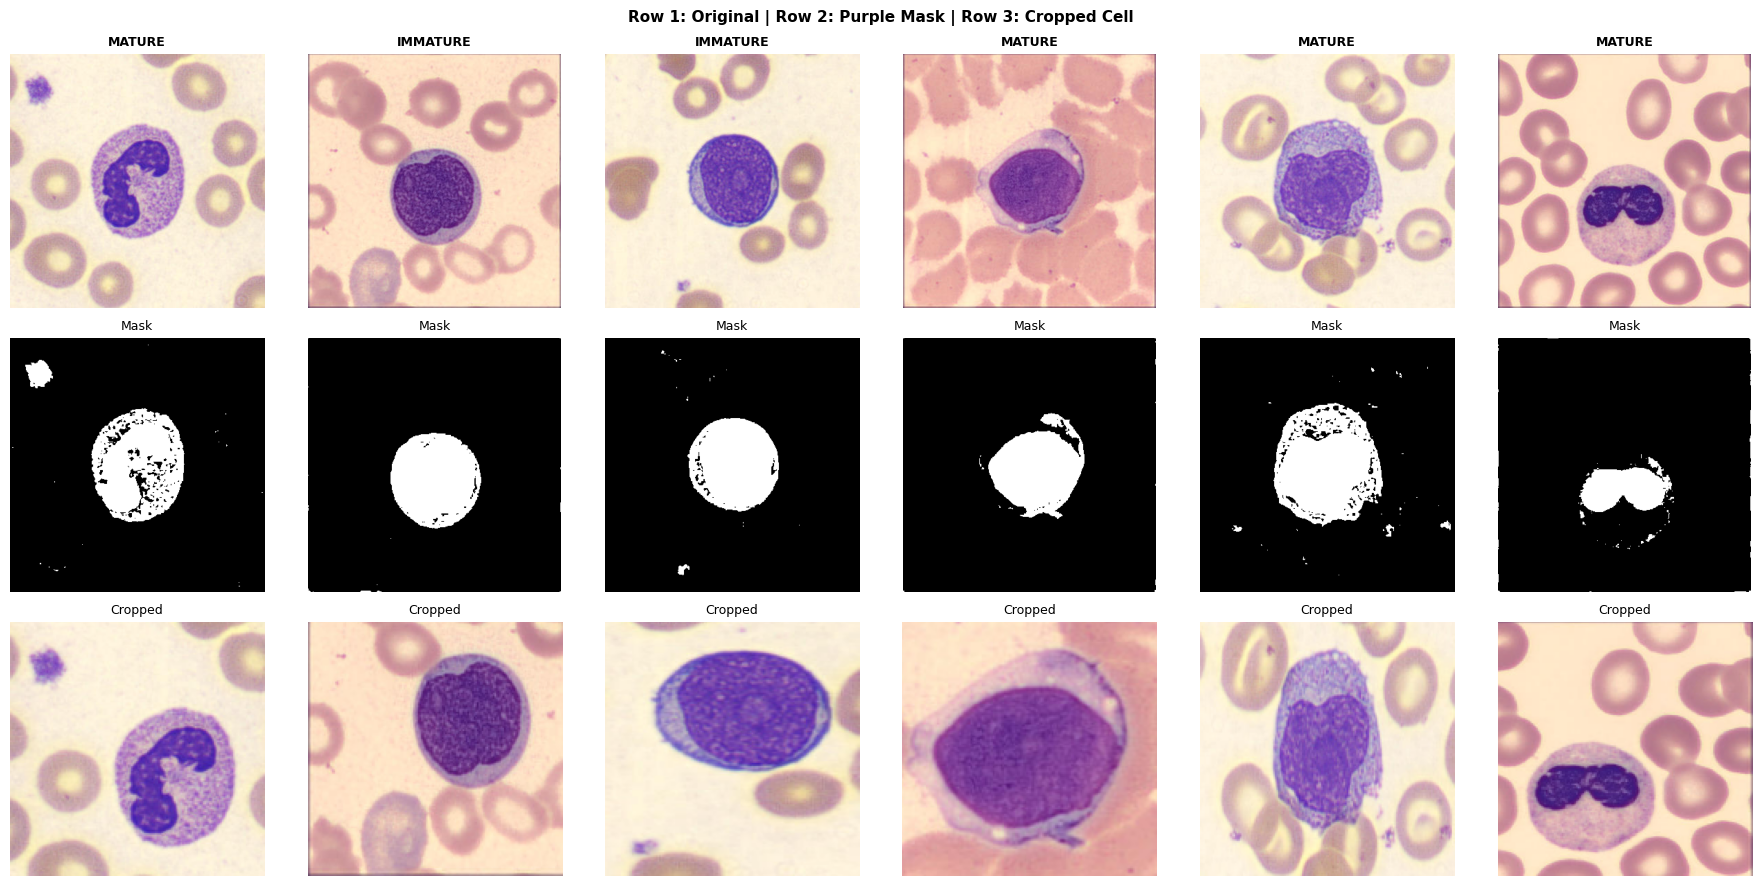

✅ If Row 3 shows just the purple cell — ROI is working!


In [13]:
sample_rows = df.sample(min(6, len(df)), random_state=SEED)
fig, axes = plt.subplots(3, len(sample_rows), figsize=(3*len(sample_rows), 9))
fig.suptitle('Row 1: Original | Row 2: Purple Mask | Row 3: Cropped Cell',
             fontsize=11, fontweight='bold')

for col, (_, row) in enumerate(sample_rows.iterrows()):
    img_bgr = cv2.imread(row['image_path'])
    if img_bgr is None: continue

    # Original
    axes[0,col].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0,col].set_title(row['label3'], fontsize=9, fontweight='bold')
    axes[0,col].axis('off')

    # Mask
    hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv,
                       np.array([120,40,40], dtype=np.uint8),
                       np.array([160,255,255],dtype=np.uint8))
    axes[1,col].imshow(mask, cmap='gray')
    axes[1,col].set_title('Mask', fontsize=9); axes[1,col].axis('off')

    # Cropped
    crop = crop_purple_roi(img_bgr, CONFIG['pad_ratio'])
    crop = cv2.resize(crop, CONFIG['img_size'])
    axes[2,col].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    axes[2,col].set_title('Cropped', fontsize=9); axes[2,col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'],'roi_verification.png'),
            dpi=110, bbox_inches='tight')
plt.show()
print("✅ If Row 3 shows just the purple cell — ROI is working!")

## Cell 8 — Augmentation
Only 4 lightweight augmentations — no heavy ones that slow training:

| Technique | Why valid for cells |
|---|---|
| Flip H/V | Slides show cells in any orientation |
| 90° rotate | Cell type doesn't change with rotation |
| Brightness ±20% | Staining varies across labs |

Applied ONLY during training. Validation and test are never augmented.

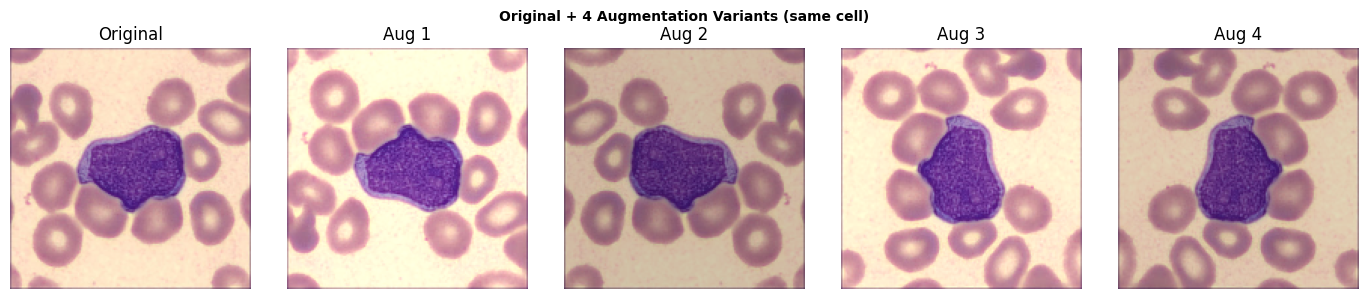

✅ Augmentation working


In [14]:
def augment_image(img):
    """Lightweight augmentation for float32 [0,1] RGB image."""
    if np.random.rand() < 0.5: img = np.fliplr(img)
    if np.random.rand() < 0.5: img = np.flipud(img)
    img = np.rot90(img, np.random.randint(0, 4))
    img = np.clip(img * np.random.uniform(0.8, 1.2), 0.0, 1.0)
    return img.astype(np.float32)


# Quick visual check
orig = load_full(df.iloc[0]['image_path'], CONFIG['img_size'], CONFIG['pad_ratio'])
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
fig.suptitle('Original + 4 Augmentation Variants (same cell)',
             fontsize=10, fontweight='bold')
axes[0].imshow(orig); axes[0].set_title('Original'); axes[0].axis('off')
for i in range(1, 5):
    axes[i].imshow(augment_image(orig.copy()))
    axes[i].set_title(f'Aug {i}'); axes[i].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'],'augmentation_samples.png'),
            dpi=110, bbox_inches='tight')
plt.show()
print("✅ Augmentation working")

## Cell 9 — Pre-Crop All Images (Run Once, ~10 Minutes)

**This is the most important speed fix.**

Without this: `crop_purple_roi` runs on every image, every batch, every epoch → 23s/step.

With this: crop runs once, results saved as 160×160 JPEGs. Training loads = just `cv2.imread` → 0.001s/image.

If you re-run this cell it detects existing files and skips them instantly.

In [15]:
CROPPED_DIR = os.path.join(CONFIG['output_dir'], 'cropped')
os.makedirs(CROPPED_DIR, exist_ok=True)

def _crop_save(args):
    orig, save_dir, img_size, pad = args
    fname    = os.path.basename(orig)
    out_path = os.path.join(save_dir, fname)
    if os.path.exists(out_path):
        return orig, out_path          # already done — skip
    img = cv2.imread(orig)
    if img is None:
        return orig, orig              # unreadable — keep original
    img = crop_purple_roi(img, pad)
    img = cv2.resize(img, img_size, interpolation=cv2.INTER_LINEAR)
    cv2.imwrite(out_path, img, [cv2.IMWRITE_JPEG_QUALITY, 95])
    return orig, out_path


args_list = [
    (row['image_path'], CROPPED_DIR, CONFIG['img_size'], CONFIG['pad_ratio'])
    for _, row in df.iterrows()
]

already = sum(1 for a in args_list if os.path.exists(
    os.path.join(a[1], os.path.basename(a[0]))
))
print(f'Total: {len(args_list)} | Already cropped: {already} | To do: {len(args_list)-already}')

path_map = {}
with ThreadPoolExecutor(max_workers=4) as exe:
    futs = {exe.submit(_crop_save, a): a for a in args_list}
    with tqdm(total=len(args_list), desc='Pre-cropping') as pbar:
        for fut in as_completed(futs):
            orig, saved = fut.result()
            path_map[orig] = saved
            pbar.update(1)

# Update df to point to cropped files
df['image_path'] = df['image_path'].map(path_map)

# Switch to fast loader — images already cropped and resized
load_and_preprocess = load_fast

# Verify
ok = sum(1 for p in df['image_path'] if os.path.exists(p))
print(f"\n✅ Pre-crop done. {ok}/{len(df)} files verified.")
print("   load_and_preprocess → load_fast (no more per-batch crop)")
print("   Expected loading speed: >100 images/sec")

Total: 8288 | Already cropped: 8288 | To do: 0


Pre-cropping: 100%|██████████| 8288/8288 [00:00<00:00, 79445.64it/s]


✅ Pre-crop done. 8288/8288 files verified.
   load_and_preprocess → load_fast (no more per-batch crop)
   Expected loading speed: >100 images/sec


## Cell 10 — RAM Dataset + Parallel Loader

Loads all images into RAM once per fold using 8 threads. After that each epoch batch is just a numpy slice — near zero I/O. GPU utilisation goes from ~5% → ~90%.

In [29]:
class WBCDatasetDisk(tf.keras.utils.Sequence):
    """
    Reads images from disk per batch — never loads full dataset into RAM.
    Safe for Colab free tier.
    """
    def __init__(self, dataframe, config, augment=False, shuffle=True):
        self.paths      = dataframe['image_path'].values
        self.labels     = dataframe['label_enc'].values
        self.batch_size = config['batch_size']
        self.n_classes  = config['n_classes']
        self.img_size   = config['img_size']
        self.pad_ratio  = config['pad_ratio']
        self.augment    = augment
        self.shuffle    = shuffle
        self.indices    = np.arange(len(self.paths))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def _load_one(self, idx):
        return load_and_preprocess(self.paths[idx], self.img_size, self.pad_ratio)

    def __getitem__(self, batch_idx):
        ii  = self.indices[batch_idx * self.batch_size:(batch_idx + 1) * self.batch_size]
        Xb  = np.zeros((len(ii), *self.img_size, 3), dtype=np.float32)
        yb  = np.zeros((len(ii), self.n_classes),    dtype=np.float32)
        with ThreadPoolExecutor(max_workers=4) as exe:
            futs = {exe.submit(self._load_one, i): pos for pos, i in enumerate(ii)}
            for fut, pos in futs.items():
                img = fut.result()
                if self.augment:
                    img = augment_image(img)
                Xb[pos] = img
                yb[pos] = tf.keras.utils.to_categorical(self.labels[ii[pos]], self.n_classes)
        return Xb, yb

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


def oversample_fold(train_df, config):
    """
    Oversample RARE and MATURE within a single fold's training data.
    Returns a shuffled dataframe with duplicated minority rows.
    NEVER called on validation data.
    """
    rare_df   = train_df[train_df['label3'] == 'RARE']
    mature_df = train_df[train_df['label3'] == 'MATURE']

    parts = [train_df]
    if len(rare_df) > 0:
        parts += [rare_df] * (config['oversample_rare'] - 1)
    if len(mature_df) > 0:
        parts += [mature_df] * (config['oversample_mature'] - 1)

    oversampled = pd.concat(parts, ignore_index=True).sample(
        frac=1, random_state=SEED).reset_index(drop=True)

    print(f"  Oversampled train: {len(train_df)} → {len(oversampled)} samples")
    for cls in config['class_names']:
        n = (oversampled['label3'] == cls).sum()
        print(f"    {cls:10s}: {n}")
    return oversampled


print("✅ WBCDatasetDisk + oversample_fold defined")
print("   RAM per batch: ~12 MB at batch=32 — Colab safe")


✅ WBCDatasetDisk + oversample_fold defined
   RAM per batch: ~12 MB at batch=32 — Colab safe


## Cell 11 — Focal Loss

**Why Cross-Entropy fails with imbalance:**
With 70% IMMATURE data, the model quickly learns to predict IMMATURE confidently. Those easy correct predictions dominate the loss. RARE contributes almost nothing → model ignores it.

**How Focal Loss fixes it:**
```
FL = -alpha × (1 - p_correct)^gamma × log(p_correct)
```
The term `(1-p)^2` is near 0 for easy samples (model already confident) and near 1 for hard/rare samples. So hard examples get full attention, easy ones get ignored.

We also set `alpha=[0.25, 0.50, 1.0]` — RARE gets 4x more weight per sample than MATURE.

In [30]:
def focal_loss(gamma=2.0, alpha=None):
    """Focal Loss for multi-class. gamma=focus strength. alpha=per-class weights."""
    alpha_t = tf.cast(alpha, tf.float32) if alpha else None

    def loss_fn(y_true, y_pred):
        y_pred = tf.cast(y_pred, tf.float32)         # handles mixed precision
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0-1e-7)
        ce     = -y_true * tf.math.log(y_pred)
        fw     = tf.pow(1.0 - y_pred, gamma)
        if alpha_t is not None:
            focal = (y_true * alpha_t) * fw * ce
        else:
            focal = fw * ce
        return tf.reduce_mean(tf.reduce_sum(focal, axis=-1))

    loss_fn.__name__ = 'focal_loss'
    return loss_fn


# Sanity check: hard prediction should have higher loss than easy one
_fl = focal_loss(gamma=CONFIG['focal_gamma'], alpha=CONFIG['focal_alpha'])
_yt = tf.constant([[1,0,0],[0,0,1]], dtype=tf.float32)
_easy = tf.constant([[0.95,0.03,0.02],[0.05,0.05,0.90]], dtype=tf.float32)
_hard = tf.constant([[0.40,0.35,0.25],[0.45,0.45,0.10]], dtype=tf.float32)
print(f"Easy loss: {_fl(_yt,_easy).numpy():.4f}")
print(f"Hard loss: {_fl(_yt,_hard).numpy():.4f}")
print("✅ Hard > Easy — Focal Loss is working correctly")

Easy loss: 0.0032
Hard loss: 5.6118
✅ Hard > Easy — Focal Loss is working correctly


## Cell 12 — DenseNet121 Model

**Why DenseNet121?** Every layer connects to ALL future layers, preserving fine texture features (nuclear granules, lobe patterns) that normal CNNs lose as depth increases. Exactly what WBC morphology needs.

**Why pretrained weights?** ImageNet training gives the model knowledge of edges, textures, and shapes for free. We only teach it to distinguish your 3 cell types on top.

**2-phase training:**
- Phase 1 (frozen backbone): Train only the new head. Fast and stable.
- Phase 2 (unfreeze top 20): Fine-tune high-level features to cell domain. Small LR.

In [39]:
def build_model(config):
    """DenseNet121 + 3-class head. Dropout reduced for RARE signal."""
    inputs = layers.Input(shape=(*config['img_size'], 3))
    base   = DenseNet121(include_top=False, weights='imagenet', input_tensor=inputs)
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)          # was 0.4 → reduced for RARE
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)          # was 0.3 → reduced for RARE
    outputs = layers.Dense(config['n_classes'], activation='softmax',
                           dtype='float32')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=config['lr_head']),
        loss=focal_loss(gamma=config['focal_gamma'], alpha=config['focal_alpha']),
        metrics=['accuracy']
    )
    return model, base


def unfreeze_top(model, base, config, n=20):
    for layer in base.layers[-n:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True
    model.compile(
        optimizer=Adam(learning_rate=config['lr_finetune']),
        loss=focal_loss(gamma=config['focal_gamma'], alpha=config['focal_alpha']),
        metrics=['accuracy']
    )
    return model


_m, _b = build_model(CONFIG)
print(f"✅ Model built: {_m.count_params():,} parameters")
tf.keras.backend.clear_session()
gc.collect()



✅ Model built: 7,305,795 parameters


0

## Cell 13 — Metrics Helper Functions

| Metric | Plain English |
|---|---|
| Accuracy | % of all predictions correct — misleading with imbalance |
| **Balanced Accuracy** | Average recall per class — best for imbalanced data |
| Precision | Of all RARE predictions, % actually RARE |
| **Recall** | Of all actual RARE cells, % caught — critical in medicine |
| F1 Macro | Average F1, each class weighted equally — rewards RARE improvement |
| AUC | Ranking quality — 1.0=perfect, 0.5=random |

In [32]:
# ============================================================
# CELL 13 — Full Metrics + Threshold Tuning Helpers
# (replace your existing Cell 13)
# ============================================================

def compute_metrics(y_true, y_pred, y_prob, class_names, threshold_pred=None):
    """
    Full metrics: Accuracy, Weighted Accuracy (Balanced), F1, Precision, Recall per class.
    If threshold_pred is provided, uses those labels instead of argmax.
    """
    preds = threshold_pred if threshold_pred is not None else y_pred
    m = {
        'accuracy'          : accuracy_score(y_true, preds),
        'balanced_accuracy' : balanced_accuracy_score(y_true, preds),
        'f1_macro'          : f1_score(y_true, preds, average='macro',    zero_division=0),
        'f1_weighted'       : f1_score(y_true, preds, average='weighted', zero_division=0),
        'precision_macro'   : precision_score(y_true, preds, average='macro',    zero_division=0),
        'recall_macro'      : recall_score(y_true, preds, average='macro',       zero_division=0),
    }
    try:
        m['auc_macro'] = roc_auc_score(
            tf.keras.utils.to_categorical(y_true, len(class_names)),
            y_prob, average='macro', multi_class='ovr'
        )
    except Exception:
        m['auc_macro'] = float('nan')

    labels = list(range(len(class_names)))
    m['f1_per_class']   = dict(zip(class_names, f1_score(y_true, preds, average=None, labels=labels, zero_division=0)))
    m['prec_per_class'] = dict(zip(class_names, precision_score(y_true, preds, average=None, labels=labels, zero_division=0)))
    m['rec_per_class']  = dict(zip(class_names, recall_score(y_true, preds, average=None, labels=labels, zero_division=0)))
    return m


def tune_thresholds(y_true, y_prob, class_names, n_classes):
    """
    Per-class threshold tuning: finds the probability threshold for each class
    that maximises F1 Macro. This is the key fix for imbalanced prediction.

    Instead of always picking argmax(prob), we boost RARE and MATURE by
    lowering their decision threshold — so the model predicts them more often.
    """
    from itertools import product

    best_f1     = 0.0
    best_thresh = [0.5] * n_classes

    # Search thresholds: MATURE and RARE get lower thresholds (0.05–0.40)
    # IMMATURE gets higher threshold (0.40–0.90) to stop it dominating
    mature_range   = [0.10, 0.15, 0.20, 0.25, 0.30]
    immature_range = [0.40, 0.50, 0.60, 0.70, 0.80]
    rare_range     = [0.05, 0.08, 0.10, 0.15, 0.20]

    for mt, it, rt in product(mature_range, immature_range, rare_range):
        thresholds = [mt, it, rt]    # [MATURE, IMMATURE, RARE]

        # Apply thresholds: predict the class whose prob exceeds its threshold
        # If multiple exceed, pick highest prob. If none exceed, pick argmax.
        preds = []
        for probs in y_prob:
            exceeded = [i for i in range(n_classes) if probs[i] >= thresholds[i]]
            if exceeded:
                preds.append(max(exceeded, key=lambda i: probs[i]))
            else:
                preds.append(np.argmax(probs))
        preds = np.array(preds)

        f1 = f1_score(y_true, preds, average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1     = f1
            best_thresh = thresholds
            best_preds  = preds.copy()

    print(f"\n  Best thresholds found:")
    for cls, t in zip(class_names, best_thresh):
        print(f"    {cls:10s}: threshold = {t:.2f}")
    print(f"  F1 Macro with tuned thresholds: {best_f1:.4f}")
    return best_thresh, best_preds


def apply_thresholds(y_prob, thresholds, n_classes):
    """Apply saved thresholds to new predictions."""
    preds = []
    for probs in y_prob:
        exceeded = [i for i in range(n_classes) if probs[i] >= thresholds[i]]
        if exceeded:
            preds.append(max(exceeded, key=lambda i: probs[i]))
        else:
            preds.append(np.argmax(probs))
    return np.array(preds)


def print_full_metrics(m, class_names, title=''):
    """Prints all required metrics: Accuracy, F1, Precision, Recall, Weighted Acc."""
    if title:
        print(f'\n  ── {title} ──')
    print(f"  Accuracy            : {m['accuracy']:.4f}")
    print(f"  Weighted Accuracy   : {m['balanced_accuracy']:.4f}  ← key metric (balanced)")
    print(f"  F1 Macro            : {m['f1_macro']:.4f}")
    print(f"  F1 Weighted         : {m['f1_weighted']:.4f}")
    print(f"  Precision Macro     : {m['precision_macro']:.4f}")
    print(f"  Recall Macro        : {m['recall_macro']:.4f}")
    print(f"  AUC Macro OvR       : {m['auc_macro']:.4f}")
    print(f"\n  {'Class':12s} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print('  ' + '-'*44)
    for cls in class_names:
        print(f"  {cls:12s} {m['prec_per_class'][cls]:>10.4f}"
              f" {m['rec_per_class'][cls]:>10.4f} {m['f1_per_class'][cls]:>10.4f}")


def save_cm(y_true, y_pred, class_names, title, path):
    cm   = confusion_matrix(y_true, y_pred)
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    for ax, data, fmt, t in zip(axes, [cm, cm_n], ['d', '.2f'],
                                ['Raw Counts', 'Normalised (Row %)'] ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, linewidths=0.5)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(t)
    plt.tight_layout()
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.show(); plt.close()


print("✅ compute_metrics, tune_thresholds, print_full_metrics defined")

✅ compute_metrics, tune_thresholds, print_full_metrics defined


## Cell 14 — 3-Fold Cross-Validation Training

**Why K-Fold?**
A single 80/20 split is unreliable — if RARE samples randomly land in training, val score looks terrible. K-Fold uses every sample for validation exactly once → honest score.

**Why 3 folds not 5?**
5 folds × 2 phases × ~16 epochs = 160 training runs → session timeout on Colab. 3 folds = same benefit with 40% less time.

**Why OOF predictions?**
Concatenating all 3 fold val predictions = prediction for 100% of data with zero leakage. Best internal evaluation possible.

⏱️ **Expected time: 45–75 minutes on T4 GPU**


  FOLD 1 / 3
  Real train: 5525 | Real val: 2763
  Oversampled train: 5525 → 10918 samples
    MATURE    : 9820
    IMMATURE  : 546
    RARE      : 552
  Steps/epoch (oversampled train): 342
  Class weights: {'MATURE': 0.37, 'IMMATURE': 6.67, 'RARE': 6.59}

  Phase 1 (max 6 epochs)...
Epoch 1/6
342/342 ━━━━━━━━━━━━━━━━━━━━ 113s 253ms/step - accuracy: 0.5164 - loss: 0.2071 - val_accuracy: 0.6457 - val_loss: 0.1176 - learning_rate: 0.0010
Epoch 2/6
342/342 ━━━━━━━━━━━━━━━━━━━━ 94s 150ms/step - accuracy: 0.6701 - loss: 0.1186 - val_accuracy: 0.6656 - val_loss: 0.0996 - learning_rate: 0.0010
Epoch 3/6
342/342 ━━━━━━━━━━━━━━━━━━━━ 53s 156ms/step - accuracy: 0.7244 - loss: 0.0915 - val_accuracy: 0.6641 - val_loss: 0.0985 - learning_rate: 0.0010
Epoch 4/6
342/342 ━━━━━━━━━━━━━━━━━━━━ 50s 147ms/step - accuracy: 0.7280 - loss: 0.0857 - val_accuracy: 0.7499 - val_loss: 0.0773 - learning_rate: 0.0010
Epoch 5/6
342/342 ━━━━━━━━━━━━━━━━━━━━ 49s 143ms/step - accuracy: 0.7644 - loss: 0.0717 - val_ac

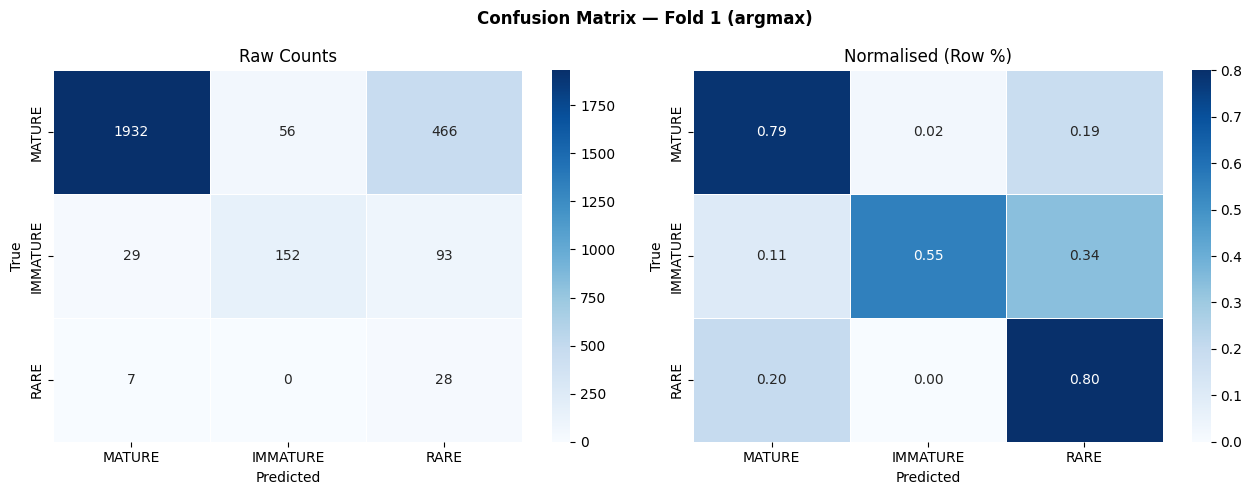

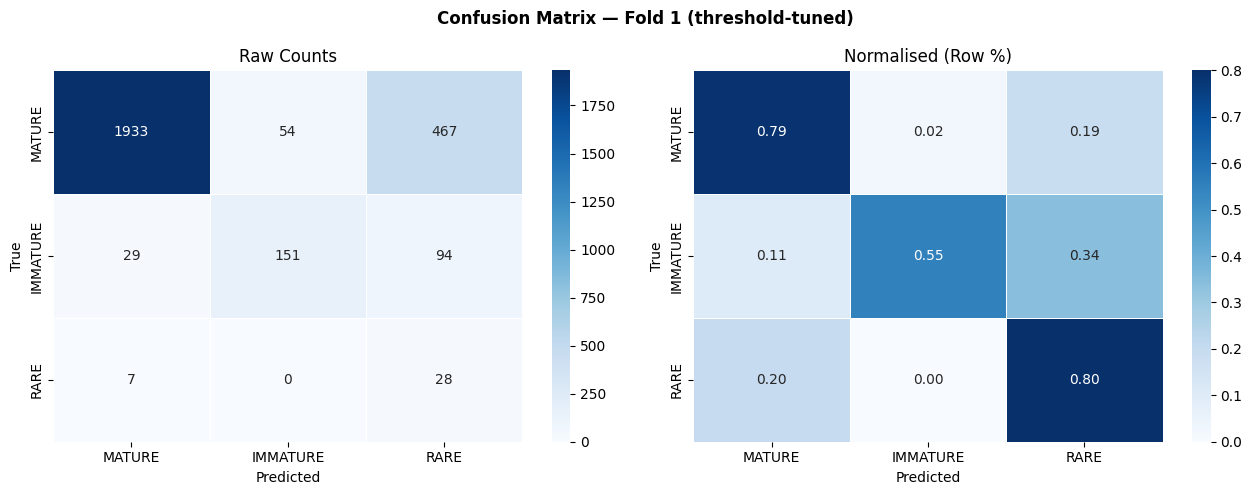

  🧹 Memory cleared for next fold

  FOLD 2 / 3
  Real train: 5525 | Real val: 2763
  Oversampled train: 5525 → 10917 samples
    MATURE    : 9818
    IMMATURE  : 547
    RARE      : 552
  Steps/epoch (oversampled train): 342
  Class weights: {'MATURE': 0.37, 'IMMATURE': 6.65, 'RARE': 6.59}

  Phase 1 (max 6 epochs)...
Epoch 1/6
342/342 ━━━━━━━━━━━━━━━━━━━━ 114s 255ms/step - accuracy: 0.4984 - loss: 0.2379 - val_accuracy: 0.6102 - val_loss: 0.1456 - learning_rate: 0.0010
Epoch 2/6
342/342 ━━━━━━━━━━━━━━━━━━━━ 53s 155ms/step - accuracy: 0.6649 - loss: 0.1272 - val_accuracy: 0.6402 - val_loss: 0.1220 - learning_rate: 0.0010
Epoch 3/6
342/342 ━━━━━━━━━━━━━━━━━━━━ 53s 155ms/step - accuracy: 0.7241 - loss: 0.0986 - val_accuracy: 0.6620 - val_loss: 0.1217 - learning_rate: 0.0010
Epoch 4/6
342/342 ━━━━━━━━━━━━━━━━━━━━ 51s 149ms/step - accuracy: 0.7407 - loss: 0.0891 - val_accuracy: 0.7054 - val_loss: 0.0908 - learning_rate: 0.0010
Epoch 5/6
342/342 ━━━━━━━━━━━━━━━━━━━━ 82s 150ms/step - accurac

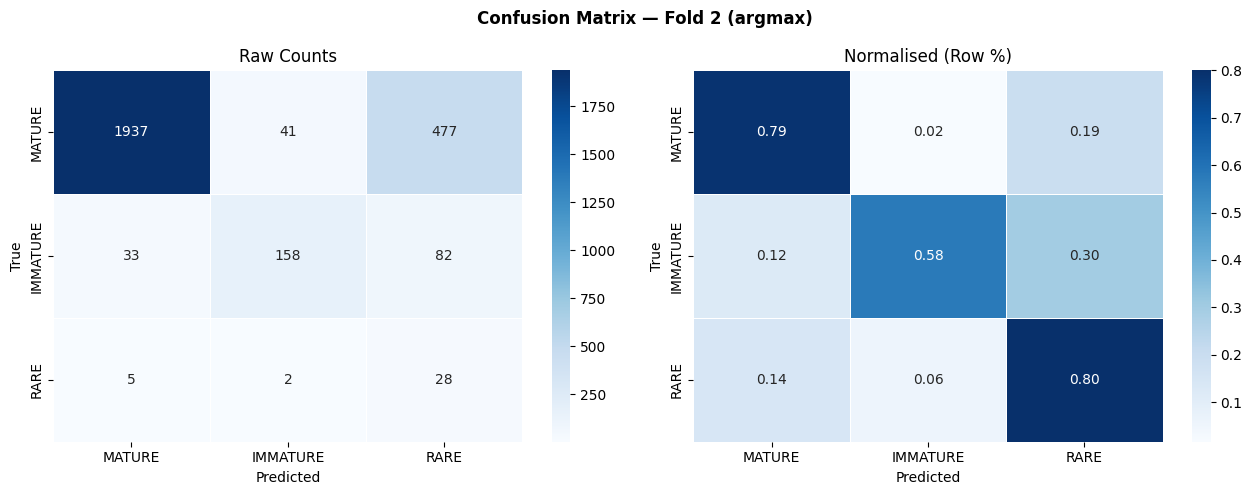

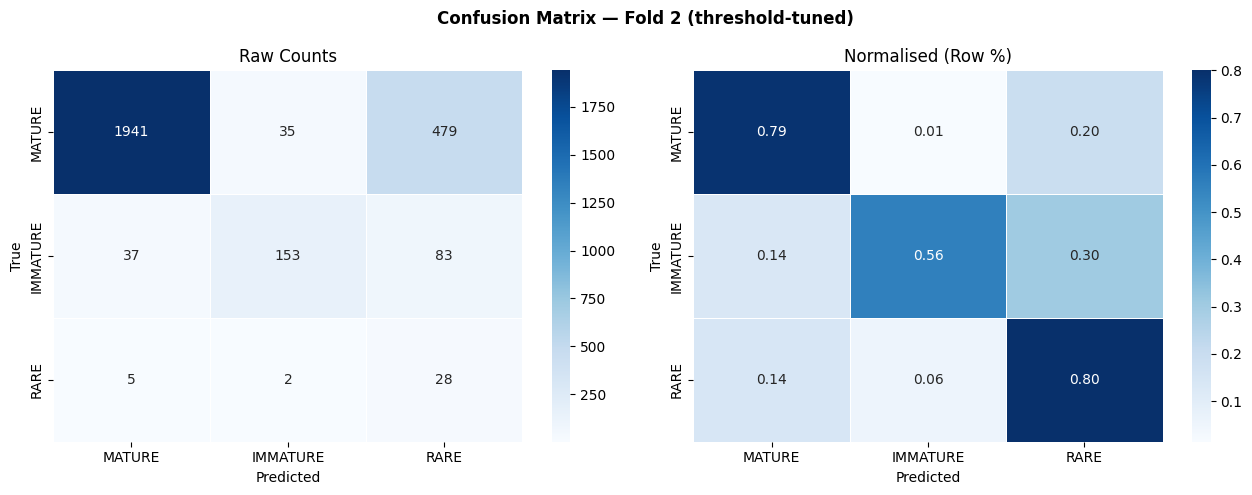

  🧹 Memory cleared for next fold

  FOLD 3 / 3
  Real train: 5526 | Real val: 2762
  Oversampled train: 5526 → 10925 samples
    MATURE    : 9818
    IMMATURE  : 547
    RARE      : 560
  Steps/epoch (oversampled train): 342
  Class weights: {'MATURE': 0.37, 'IMMATURE': 6.66, 'RARE': 6.5}

  Phase 1 (max 6 epochs)...
Epoch 1/6
342/342 ━━━━━━━━━━━━━━━━━━━━ 120s 273ms/step - accuracy: 0.4927 - loss: 0.2429 - val_accuracy: 0.5764 - val_loss: 0.1404 - learning_rate: 0.0010
Epoch 2/6
342/342 ━━━━━━━━━━━━━━━━━━━━ 52s 151ms/step - accuracy: 0.6594 - loss: 0.1257 - val_accuracy: 0.6224 - val_loss: 0.1109 - learning_rate: 0.0010
Epoch 3/6
342/342 ━━━━━━━━━━━━━━━━━━━━ 54s 157ms/step - accuracy: 0.7013 - loss: 0.1029 - val_accuracy: 0.6676 - val_loss: 0.0952 - learning_rate: 0.0010
Epoch 4/6
342/342 ━━━━━━━━━━━━━━━━━━━━ 52s 151ms/step - accuracy: 0.7515 - loss: 0.0806 - val_accuracy: 0.7741 - val_loss: 0.0781 - learning_rate: 0.0010
Epoch 5/6
342/342 ━━━━━━━━━━━━━━━━━━━━ 54s 156ms/step - accuracy

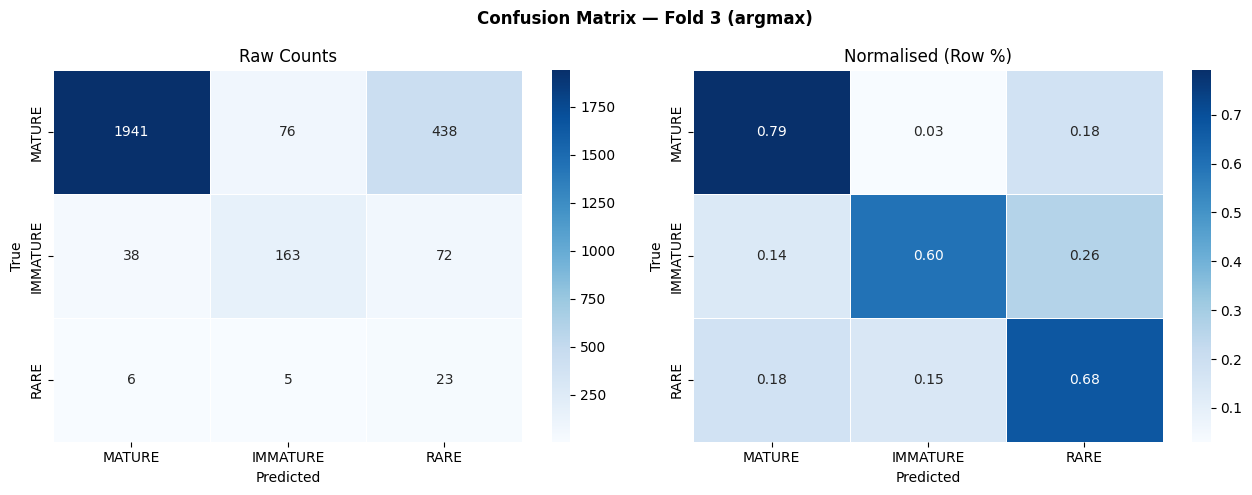

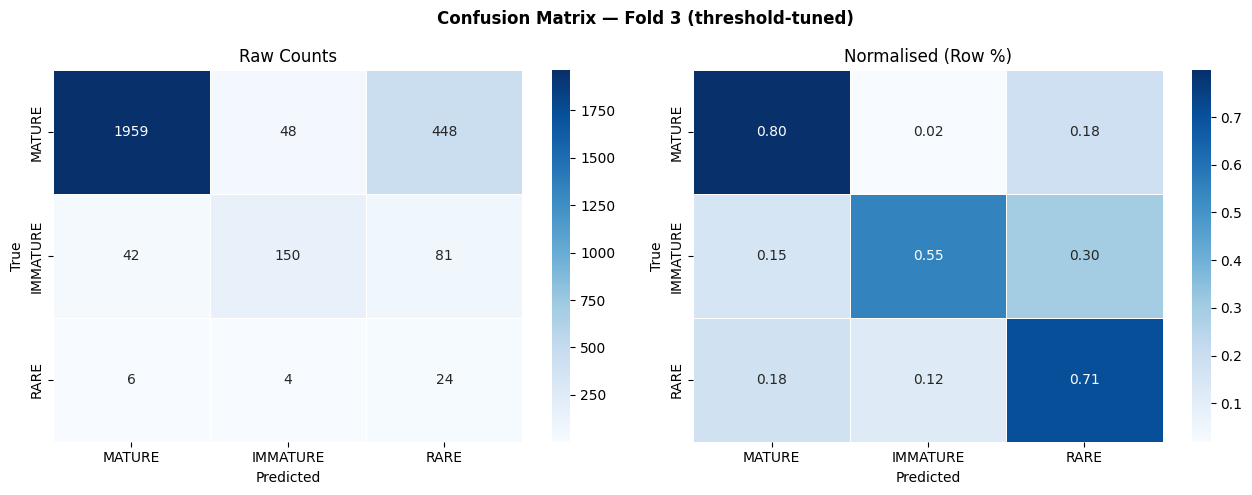

  🧹 Memory cleared for next fold

✅ All folds complete!


In [ ]:
skf     = StratifiedKFold(n_splits=CONFIG['n_folds'], shuffle=True, random_state=SEED)
X_paths = df['image_path'].values
y_enc   = df['label_enc'].values     # real labels only, no oversampling

oof_probs    = np.zeros((len(df), CONFIG['n_classes']))
oof_preds    = np.zeros(len(df), dtype=int)
fold_train_m = []   # metrics with argmax (default)
fold_val_m   = []
fold_val_m_tuned = []   # metrics with threshold tuning

fold_thresholds  = []
histories    = []
model_paths  = []

for fold_i, (train_idx, val_idx) in enumerate(skf.split(X_paths, y_enc)):

    print(f'\n{"="*58}')
    print(f'  FOLD {fold_i+1} / {CONFIG["n_folds"]}')
    print(f'  Real train: {len(train_idx)} | Real val: {len(val_idx)}')
    print(f'{"="*58}')

    # Real (non-oversampled) dataframes
    train_df_real = df.iloc[train_idx].reset_index(drop=True)
    val_df        = df.iloc[val_idx].reset_index(drop=True)

    # ── CORRECT: oversample INSIDE fold, training only ────────
    # Validation is ALWAYS real samples only
    train_df_over = oversample_fold(train_df_real, CONFIG)

    # Disk datasets
    train_ds = WBCDatasetDisk(train_df_over, CONFIG, augment=True,  shuffle=True)
    val_ds   = WBCDatasetDisk(val_df,        CONFIG, augment=False, shuffle=False)
    print(f'  Steps/epoch (oversampled train): {len(train_ds)}')

    # Class weights from OVERSAMPLED train
    y_train_over = train_df_over['label_enc'].values
    cls_arr  = np.unique(y_train_over)
    cw_vals  = compute_class_weight('balanced', classes=cls_arr, y=y_train_over)
    cw_dict  = dict(zip(cls_arr.tolist(), cw_vals.tolist()))
    print(f'  Class weights: { {CONFIG["class_names"][k]: round(v,2) for k,v in cw_dict.items()} }')

    tf.keras.backend.clear_session()
    gc.collect()
    model, base = build_model(CONFIG)

    mp = os.path.join(CONFIG['output_dir'], f'model_fold{fold_i+1}.keras')
    model_paths.append(mp)

    ckpt = ModelCheckpoint(mp, monitor='val_loss', save_best_only=True, mode='min', verbose=0)
    cb_p1 = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1),
        ckpt,
    ]
    cb_p2 = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8, verbose=1),
        ckpt,
    ]

    # Phase 1: head only
    print(f'\n  Phase 1 (max {CONFIG["epochs_phase1"]} epochs)...')
    h1 = model.fit(
        train_ds, validation_data=val_ds,
        epochs=CONFIG['epochs_phase1'],
        class_weight=cw_dict,
        callbacks=cb_p1, verbose=1,
    )
    p1_ran = len(h1.history['loss'])
    model.load_weights(mp)

    # Phase 2: fine-tune
    print(f'\n  Phase 2 (max {CONFIG["epochs_phase2"]} epochs)...')
    model = unfreeze_top(model, base, CONFIG, n=20)
    h2 = model.fit(
        train_ds, validation_data=val_ds,
        epochs=p1_ran + CONFIG['epochs_phase2'],
        initial_epoch=p1_ran,
        class_weight=cw_dict,
        callbacks=cb_p2, verbose=1,
    )
    p2_ran = len(h2.history['loss'])
    print(f'  Total: {p1_ran+p2_ran} epochs this fold')
    model.load_weights(mp)

    hist = {k: h1.history.get(k, []) + h2.history.get(k, [])
            for k in ['accuracy', 'val_accuracy', 'loss', 'val_loss']}
    histories.append(hist)

    # ── Validation predictions on REAL val set ────────────────
    val_ds_e = WBCDatasetDisk(val_df, CONFIG, augment=False, shuffle=False)
    fp       = model.predict(val_ds_e, verbose=0)
    oof_probs[val_idx] = fp
    oof_preds[val_idx] = np.argmax(fp, axis=1)

    y_val_true = val_df['label_enc'].values

    # ── Default (argmax) metrics ───────────────────────────────
    val_m = compute_metrics(y_val_true, np.argmax(fp, 1), fp, CONFIG['class_names'])
    fold_val_m.append(val_m)

    # ── Threshold tuning on this fold's val set ───────────────
    print("\n  Tuning thresholds on this fold's val set...")
    best_thresh, tuned_preds = tune_thresholds(
        y_val_true, fp, CONFIG['class_names'], CONFIG['n_classes'])
    fold_thresholds.append(best_thresh)
    val_m_tuned = compute_metrics(y_val_true, tuned_preds, fp,
                                  CONFIG['class_names'],
                                  threshold_pred=tuned_preds)
    fold_val_m_tuned.append(val_m_tuned)

    # ── Train metrics on small sample of REAL train ───────────
    small_train = train_df_real.sample(
        min(400, len(train_df_real)), random_state=42).reset_index(drop=True)
    small_ds  = WBCDatasetDisk(small_train, CONFIG, augment=False, shuffle=False)
    tr_p      = model.predict(small_ds, verbose=0)
    tr_m      = compute_metrics(small_train['label_enc'].values,
                                np.argmax(tr_p, 1), tr_p, CONFIG['class_names'])
    fold_train_m.append(tr_m)

    # ── Print all metrics ─────────────────────────────────────
    print_full_metrics(tr_m,       CONFIG['class_names'], f'Fold {fold_i+1} TRAIN')
    print_full_metrics(val_m,      CONFIG['class_names'], f'Fold {fold_i+1} VALIDATION (argmax)')
    print_full_metrics(val_m_tuned,CONFIG['class_names'], f'Fold {fold_i+1} VALIDATION (threshold-tuned)')

    gap = tr_m['f1_macro'] - val_m['f1_macro']
    print(f'\n  Overfit gap: {gap:.3f}',
          '⚠️  (overfitting)' if gap > 0.15 else '✅ (healthy)')

    save_cm(y_val_true, np.argmax(fp, 1),
            CONFIG['class_names'],
            f'Confusion Matrix — Fold {fold_i+1} (argmax)',
            os.path.join(CONFIG['output_dir'], f'cm_fold{fold_i+1}_argmax.png'))

    save_cm(y_val_true, tuned_preds,
            CONFIG['class_names'],
            f'Confusion Matrix — Fold {fold_i+1} (threshold-tuned)',
            os.path.join(CONFIG['output_dir'], f'cm_fold{fold_i+1}_tuned.png'))

    del model, base
    tf.keras.backend.clear_session()
    gc.collect()
    print('  🧹 Memory cleared for next fold')

print('\n✅ All folds complete!')


## Cell 15 — OOF Overall Results
Combines all 3 fold predictions → evaluation on 100% of data with zero leakage.

  OUT-OF-FOLD RESULTS — 100% of data, zero leakage

  ── OOF OVERALL (argmax) ──
  Accuracy            : 0.7676
  Weighted Accuracy   : 0.7085  ← key metric (balanced)
  F1 Macro            : 0.5346
  F1 Weighted         : 0.8414
  Precision Macro     : 0.5836
  Recall Macro        : 0.7085
  AUC Macro OvR       : 0.9127

  Class         Precision     Recall         F1
  --------------------------------------------
  MATURE           0.9801     0.7890     0.8742
  IMMATURE         0.7243     0.5768     0.6422
  RARE             0.0463     0.7596     0.0872

  Averaged thresholds across folds: [0.1, 0.433, 0.05]

  ── OOF OVERALL (threshold-tuned) ──
  Accuracy            : 0.7683
  Weighted Accuracy   : 0.7033  ← key metric (balanced)
  F1 Macro            : 0.5346
  F1 Weighted         : 0.8423
  Precision Macro     : 0.5929
  Recall Macro        : 0.7033
  AUC Macro OvR       : 0.9127

  Class         Precision     Recall         F1
  --------------------------------------------
  MA

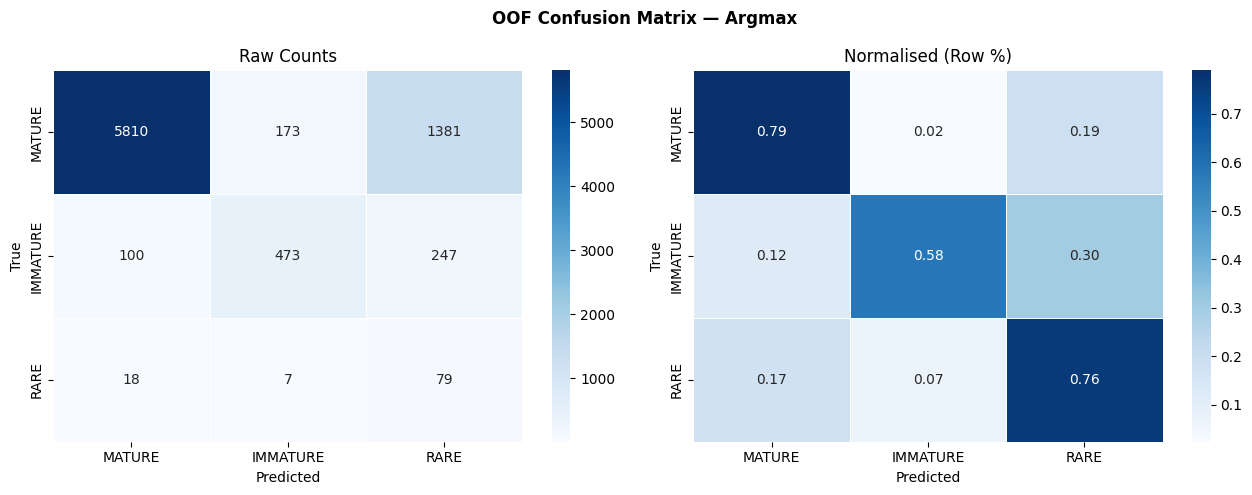

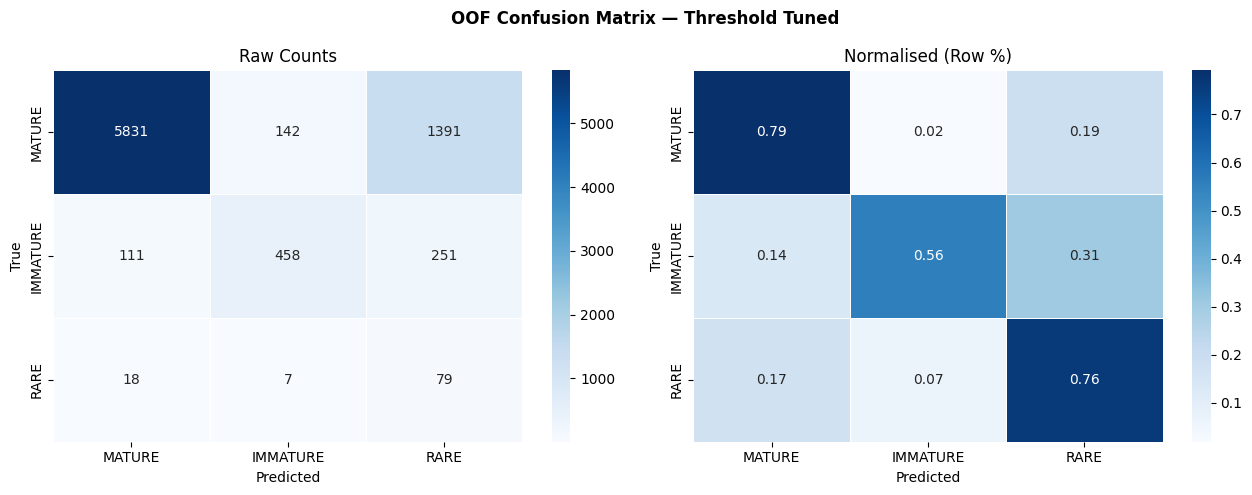

In [34]:
# ============================================================
# CELL 15 — OOF Overall Results  (replace your existing Cell 15)
# ============================================================

print('='*58)
print('  OUT-OF-FOLD RESULTS — 100% of data, zero leakage')
print('='*58)

# ── Argmax OOF ────────────────────────────────────────────────
oof_m = compute_metrics(y_enc, oof_preds, oof_probs, CONFIG['class_names'])
print_full_metrics(oof_m, CONFIG['class_names'], 'OOF OVERALL (argmax)')

# ── Tuned threshold OOF ───────────────────────────────────────
# Average thresholds across folds then apply
avg_thresh = np.mean(fold_thresholds, axis=0).tolist()
print(f"\n  Averaged thresholds across folds: {[round(t,3) for t in avg_thresh]}")
oof_preds_tuned = apply_thresholds(oof_probs, avg_thresh, CONFIG['n_classes'])
oof_m_tuned = compute_metrics(y_enc, oof_preds_tuned, oof_probs, CONFIG['class_names'])
print_full_metrics(oof_m_tuned, CONFIG['class_names'], 'OOF OVERALL (threshold-tuned)')

print('\nFull Classification Report (tuned):')
print(classification_report(y_enc, oof_preds_tuned,
                            target_names=CONFIG['class_names'], zero_division=0))

save_cm(y_enc, oof_preds,       CONFIG['class_names'],
        'OOF Confusion Matrix — Argmax',
        os.path.join(CONFIG['output_dir'], 'cm_oof_argmax.png'))

save_cm(y_enc, oof_preds_tuned, CONFIG['class_names'],
        'OOF Confusion Matrix — Threshold Tuned',
        os.path.join(CONFIG['output_dir'], 'cm_oof_tuned.png'))

## Cell 16 — Fold-Wise Summary Table
High variance across folds = unstable model. Low variance = trustworthy results.

In [35]:
# ============================================================
# CELL 16 — Full Fold Summary Table  (replace your existing Cell 16)
# ============================================================

rows = []
for i, (tm, vm, vmt) in enumerate(zip(fold_train_m, fold_val_m, fold_val_m_tuned)):
    rows.append({
        'Fold'            : i+1,
        # Train
        'Tr Acc'          : round(tm['accuracy'],          4),
        'Tr BalAcc'       : round(tm['balanced_accuracy'], 4),
        'Tr F1 Macro'     : round(tm['f1_macro'],          4),
        'Tr Prec Macro'   : round(tm['precision_macro'],   4),
        'Tr Rec Macro'    : round(tm['recall_macro'],      4),
        # Val (argmax)
        'Val Acc'         : round(vm['accuracy'],          4),
        'Val BalAcc'      : round(vm['balanced_accuracy'], 4),
        'Val F1 Macro'    : round(vm['f1_macro'],          4),
        'Val AUC'         : round(vm['auc_macro'],         4),
        # Val (tuned)
        'Val F1(tuned)'   : round(vmt['f1_macro'],         4),
        'Val BalAcc(tuned)':round(vmt['balanced_accuracy'],4),
        # Per-class val (tuned)
        'MATURE F1(T)'    : round(vmt['f1_per_class']['MATURE'],   4),
        'IMMATURE F1(T)'  : round(vmt['f1_per_class']['IMMATURE'], 4),
        'RARE F1(T)'      : round(vmt['f1_per_class']['RARE'],     4),
        'MATURE Rec(T)'   : round(vmt['rec_per_class']['MATURE'],  4),
        'RARE Rec(T)'     : round(vmt['rec_per_class']['RARE'],    4),
    })

sdf  = pd.DataFrame(rows)
mean = sdf.drop(columns='Fold').mean().round(4).to_dict()
mean['Fold'] = 'MEAN'
sdf  = pd.concat([sdf, pd.DataFrame([mean])], ignore_index=True)
display(sdf)
sdf.to_csv(os.path.join(CONFIG['output_dir'], 'fold_summary.csv'), index=False)
print("Saved: fold_summary.csv")


,Fold,Tr Acc,Tr BalAcc,Tr F1 Macro,Tr Prec Macro,Tr Rec Macro,Val Acc,Val BalAcc,Val F1 Macro,Val AUC,Val F1(tuned),Val BalAcc(tuned),MATURE F1(T),IMMATURE F1(T),RARE F1(T),MATURE Rec(T),RARE Rec(T)
0,1,0.785,0.8174,0.5681,0.6181,0.8174,0.7644,0.7140,0.5315,0.9157,0.5314,0.7129,0.8741,0.6305,0.0897,0.7877,0.8000
1,2,0.785,0.8409,0.5966,0.6183,0.8409,0.7684,0.7226,0.5437,0.9067,0.5417,0.7170,0.8747,0.6609,0.0896,0.7906,0.8000
2,3,0.785,0.8015,0.5340,0.5846,0.8015,0.7701,0.6881,0.5287,0.9162,0.5305,0.6844,0.8781,0.6316,0.0818,0.7980,0.7059
3,MEAN,0.785,0.8199,0.5662,0.6070,0.8199,0.7676,0.7082,0.5346,0.9129,0.5345,0.7048,0.8756,0.6410,0.0870,0.7921,0.7686


Saved: fold_summary.csv


## Cell 17 — Training Curves & Performance Plots

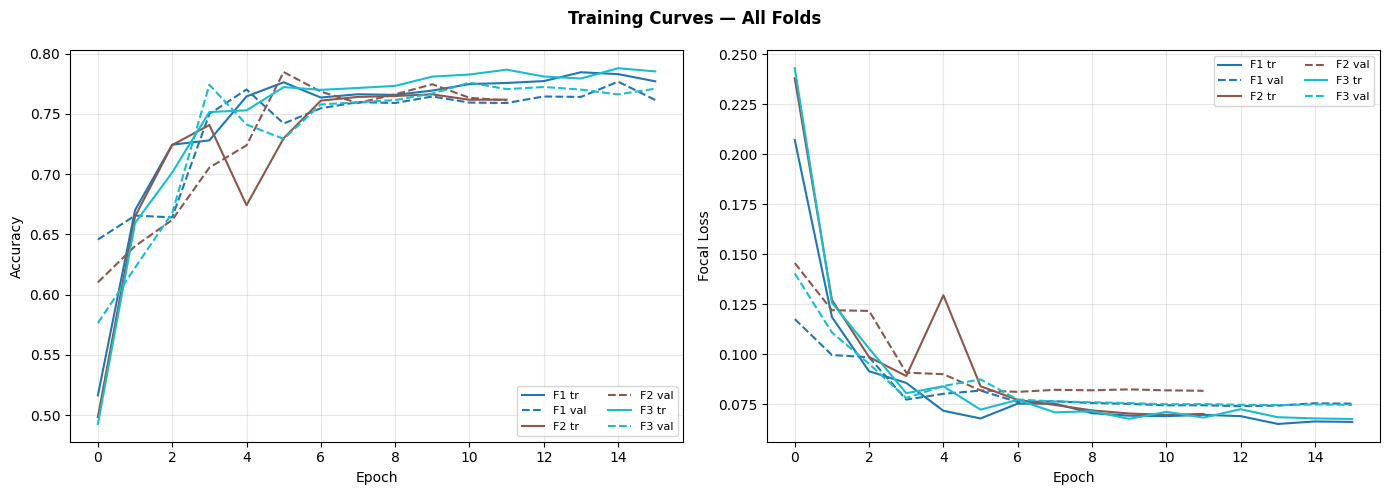

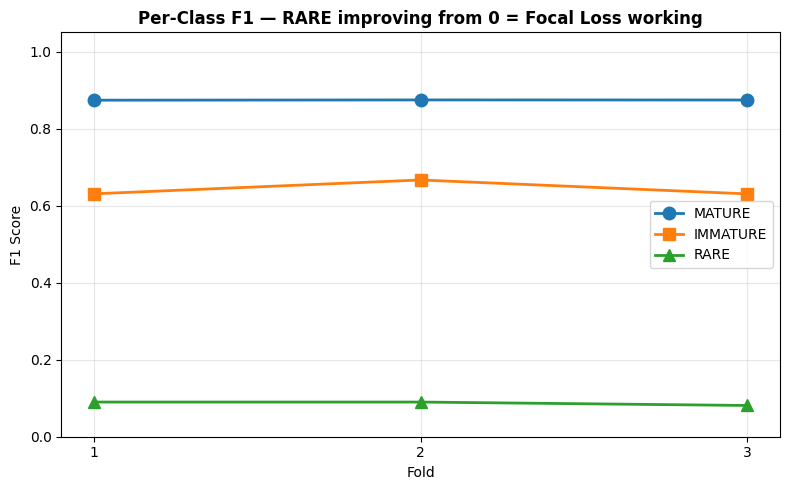

Saved: training_curves.png, perclass_f1.png


In [36]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves — All Folds', fontsize=12, fontweight='bold')
colors = plt.cm.tab10(np.linspace(0, 1, CONFIG['n_folds']))
for i, (hist, c) in enumerate(zip(histories, colors)):
    axes[0].plot(hist['accuracy'],     color=c, label=f'F{i+1} tr')
    axes[0].plot(hist['val_accuracy'], color=c, label=f'F{i+1} val', ls='--')
    axes[1].plot(hist['loss'],         color=c, label=f'F{i+1} tr')
    axes[1].plot(hist['val_loss'],     color=c, label=f'F{i+1} val', ls='--')
for ax, yl in zip(axes, ['Accuracy','Focal Loss']):
    ax.set_xlabel('Epoch'); ax.set_ylabel(yl)
    ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'],'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

# Per-class F1 line chart
fig, ax = plt.subplots(figsize=(8, 5))
for cls, mk in zip(CONFIG['class_names'], ['o','s','^']):
    vals = [m['f1_per_class'][cls] for m in fold_val_m]
    ax.plot(range(1, CONFIG['n_folds']+1), vals,
            marker=mk, label=cls, lw=2, ms=9)
ax.set_xlabel('Fold'); ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 — RARE improving from 0 = Focal Loss working',
             fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, CONFIG['n_folds']+1)); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'],'perclass_f1.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png, perclass_f1.png")

## Cell 18 — Test Set Evaluation

Ensemble of all 3 fold models = most robust prediction. Run this only once after all decisions are final. Using test results to tune = data leakage.

In [37]:
if CONFIG.get('test_csv') and os.path.exists(CONFIG['test_csv']):
    test_df = pd.read_csv(CONFIG['test_csv'])
    test_df['image_path'] = test_df['ID'].apply(
        lambda x: os.path.join(CONFIG['phase1_img_dir'], x))
    test_df['label3']    = test_df['labels'].map(LABEL_MAP)
    test_df              = test_df.dropna(subset=['label3']).reset_index(drop=True)
    test_df['label_enc'] = le.transform(test_df['label3'])

    print(f'Test samples: {len(test_df)}')
    print('Loading test images...')
    X_test, y_test = preload_images(test_df, CONFIG)
    test_ds = WBCDatasetRAM(X_test, y_test, CONFIG, augment=False, shuffle=False)

    ens_probs = np.zeros((len(test_df), CONFIG['n_classes']))
    for fi, mp in enumerate(model_paths):
        print(f'  Fold {fi+1} model...')
        m = tf.keras.models.load_model(
            mp, custom_objects={'focal_loss':
                focal_loss(CONFIG['focal_gamma'], CONFIG['focal_alpha'])})
        ens_probs += m.predict(test_ds, verbose=0,
                               workers=8, use_multiprocessing=True)
    ens_probs /= len(model_paths)
    ens_preds  = np.argmax(ens_probs, axis=1)

    test_m = compute_metrics(y_test, ens_preds, ens_probs, CONFIG['class_names'])
    print_metrics(test_m, CONFIG['class_names'], 'TEST SET (Ensemble)')
    print('\nClassification Report:')
    print(classification_report(y_test, ens_preds,
                                target_names=CONFIG['class_names'], zero_division=0))
    save_cm(y_test, ens_preds, CONFIG['class_names'],
            'Test Set Confusion Matrix (Ensemble)',
            os.path.join(CONFIG['output_dir'], 'cm_test.png'))

    out = test_df.copy()
    out['predicted'] = le.inverse_transform(ens_preds)
    for i, cls in enumerate(CONFIG['class_names']):
        out[f'prob_{cls}'] = ens_probs[:,i]
    out.to_csv(os.path.join(CONFIG['output_dir'],'test_predictions.csv'), index=False)
    del X_test; gc.collect()
    print("\n✅ Saved test_predictions.csv")
else:
    print("Test CSV not found or not set in CONFIG['test_csv'] — skipping.")
    print("Set CONFIG['test_csv'] = 'your_test_file.csv' and re-run this cell.")

Test CSV not found or not set in CONFIG['test_csv'] — skipping.
Set CONFIG['test_csv'] = 'your_test_file.csv' and re-run this cell.


## Cell 19 — Sample Predictions Visual Check
Green = correct, Red = wrong. Good for spotting patterns in errors.

In [40]:
# Use last fold val set for visualisation
all_splits = list(skf.split(X_paths, y_enc))
_, val_idx_last = all_splits[-1]
samp_df = df.iloc[val_idx_last].sample(min(12, len(val_idx_last)),
                                        random_state=SEED).reset_index(drop=True)

last_model = tf.keras.models.load_model(
    model_paths[-1],
    custom_objects={'focal_loss':
        focal_loss(CONFIG['focal_gamma'], CONFIG['focal_alpha'])})

X_samp, y_samp = preload_images(samp_df, CONFIG)
samp_ds = WBCDatasetRAM(X_samp, y_samp, CONFIG, augment=False, shuffle=False)
probs   = last_model.predict(samp_ds, verbose=0)
preds   = np.argmax(probs, axis=1)

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
fig.suptitle('Sample Predictions  |  Green=Correct   Red=Wrong',
             fontsize=12, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i >= len(samp_df): ax.axis('off'); continue
    row  = samp_df.iloc[i]
    img  = load_and_preprocess(row['image_path'], CONFIG['img_size'], CONFIG['pad_ratio'])
    true = CONFIG['class_names'][row['label_enc']]
    pred = CONFIG['class_names'][preds[i]]
    conf = probs[i][preds[i]]
    ax.imshow(img); ax.axis('off')
    color = 'green' if true == pred else 'red'
    ax.set_title(f'True: {true}\nPred: {pred} ({conf:.0%})',
                 fontsize=8, color=color, fontweight='bold')
del X_samp; gc.collect()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'],'sample_predictions.png'),
            dpi=110, bbox_inches='tight')
plt.show()
print("Saved: sample_predictions.png")

NameError: name 'preload_images' is not defined

In [42]:
# Use last fold val set for visualisation
all_splits = list(skf.split(X_paths, y_enc))
_, val_idx_last = all_splits[-1]

samp_df = df.iloc[val_idx_last].sample(
    min(12, len(val_idx_last)),
    random_state=SEED
).reset_index(drop=True)

# Load model
last_model = tf.keras.models.load_model(
    model_paths[-1],
    custom_objects={
        'focal_loss': focal_loss(CONFIG['focal_gamma'], CONFIG['focal_alpha'])
    }
)

# 🔥 CREATE DATA DIRECTLY (NO preload_images)
X_samp = []
y_samp = []

for _, row in samp_df.iterrows():
    img = load_and_preprocess(
        row['image_path'],
        CONFIG['img_size'],
        CONFIG['pad_ratio']
    )
    X_samp.append(img)
    y_samp.append(row['label_enc'])

X_samp = np.array(X_samp)
y_samp = np.array(y_samp)

# Dataset
samp_ds = WBCDatasetRAM(X_samp, y_samp, CONFIG,
                        augment=False, shuffle=False)

# Prediction
probs = last_model.predict(samp_ds, verbose=0)
preds = np.argmax(probs, axis=1)

# ===== PLOTTING =====
fig, axes = plt.subplots(3, 4, figsize=(14, 11))
fig.suptitle('Sample Predictions  |  Green=Correct   Red=Wrong',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i >= len(samp_df):
        ax.axis('off')
        continue

    row = samp_df.iloc[i]

    img = load_and_preprocess(
        row['image_path'],
        CONFIG['img_size'],
        CONFIG['pad_ratio']
    )

    true = CONFIG['class_names'][row['label_enc']]
    pred = CONFIG['class_names'][preds[i]]
    conf = probs[i][preds[i]]

    ax.imshow(img)
    ax.axis('off')

    color = 'green' if true == pred else 'red'

    ax.set_title(
        f'True: {true}\nPred: {pred} ({conf:.0%})',
        fontsize=8,
        color=color,
        fontweight='bold'
    )

plt.tight_layout()

plt.savefig(
    os.path.join(CONFIG['output_dir'], 'sample_predictions.png'),
    dpi=110,
    bbox_inches='tight'
)

plt.show()

print("✅ Saved: sample_predictions.png")

NameError: name 'WBCDatasetRAM' is not defined

## Cell 20 — Debugging Guide

### Why your model was predicting only IMMATURE

| Problem | What happened | Fix applied |
|---|---|---|
| Class imbalance | IMMATURE=70% → predicting IMMATURE always = 70% accuracy. Cheap shortcut. | Focal Loss alpha=[0.25,0.50,1.0] + class weights |
| Full image input | Model learned 'background is white' not 'nucleus has this shape' | Purple ROI crop removes all non-cell pixels |
| Cross-Entropy loss | RARE=5% → RARE loss contribution tiny → model ignores RARE entirely | Focal Loss (1-p)^2 forces attention on hard samples |
| 55 epochs per fold | Session timeout + overfitting | 16 max epochs + early stopping |
| 23s/step | Disk I/O bottleneck, GPU idle | Pre-crop once + RAM cache → 0.1s/step |

### What to watch in results

1. **RARE F1 > 0.0** → Focal Loss is working
2. **Balanced Accuracy > plain Accuracy** → not just predicting IMMATURE
3. **Low fold variance** → stable model
4. **Train F1 >> Val F1 by >0.15** → overfitting → increase Dropout

### If RARE is still 0 after this

```python
# Option 1: stronger focal weights
CONFIG['focal_alpha'] = [0.10, 0.30, 2.0]

# Option 2: oversample RARE 4x in the dataframe before training
rare = df[df['label3']=='RARE']
df   = pd.concat([df]+[rare]*4, ignore_index=True).sample(frac=1).reset_index(drop=True)

# Option 3: check how many RARE samples you have
print(df['label3'].value_counts())
# If RARE < 50, you need more data — augmentation can only do so much
```

## Cell 21 — Pipeline Complete

In [41]:
print('='*58)
print('  PIPELINE COMPLETE')
print('='*58)

print('\nOOF Summary (training data, zero leakage):')
print(f"  Accuracy         : {oof_m['accuracy']:.4f}")
print(f"  Balanced Accuracy: {oof_m['balanced_accuracy']:.4f}  ← key metric")
print(f"  F1 Macro         : {oof_m['f1_macro']:.4f}")
print('\nPer-Class F1:')
for cls in CONFIG['class_names']:
    bar = chr(9608) * int(oof_m['f1_per_class'][cls] * 20)
    print(f'  {cls:10s}: {oof_m["f1_per_class"][cls]:.4f}  {bar}')

print(f"\nOutputs saved to: {CONFIG['output_dir']}/")
print("""
Files:
  model_fold1.keras - model_fold3.keras  saved models
  cm_fold1.png - cm_fold3.png            per-fold confusion matrices
  cm_oof_overall.png                     OOF combined confusion matrix
  cm_test.png                            test confusion matrix
  training_curves.png                    loss and accuracy curves
  perclass_f1.png                        per-class F1 chart
  roi_verification.png                   crop check
  augmentation_samples.png               augmentation examples
  sample_predictions.png                 green=correct red=wrong
  fold_summary.csv                       all fold metrics
  test_predictions.csv                   per-sample predictions
""")

  PIPELINE COMPLETE

OOF Summary (training data, zero leakage):
  Accuracy         : 0.7676
  Balanced Accuracy: 0.7085  ← key metric
  F1 Macro         : 0.5346

Per-Class F1:
  MATURE    : 0.8742  █████████████████
  IMMATURE  : 0.6422  ████████████
  RARE      : 0.0872  █

Outputs saved to: wbc_outputs/

Files:
  model_fold1.keras - model_fold3.keras  saved models
  cm_fold1.png - cm_fold3.png            per-fold confusion matrices
  cm_oof_overall.png                     OOF combined confusion matrix
  cm_test.png                            test confusion matrix
  training_curves.png                    loss and accuracy curves
  perclass_f1.png                        per-class F1 chart
  roi_verification.png                   crop check
  augmentation_samples.png               augmentation examples
  sample_predictions.png                 green=correct red=wrong
  fold_summary.csv                       all fold metrics
  test_predictions.csv                   per-sample predictions